# PIB total vs PIB per cápita en la UE

Comparamos dos formas de medir "cuánto crece la economía":

- **Crecimiento del PIB real** (tamaño total de la economía).
- **PIB per cápita en PPS** (lo que le corresponde a cada habitante, ajustado por poder adquisitivo).

Fuente: Eurostat (`tec00114`, `tec00115`). Si no se ha ejecutado `fetch_data.py`, se usan datos de ejemplo **ilustrativos** en `data/sample_pib.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

REAL_PATH = Path("data/pib_real.csv")
SAMPLE_PATH = Path("data/sample_pib.csv")

if REAL_PATH.exists():
    print("Usando datos reales descargados de Eurostat (data/pib_real.csv)")
    df_raw = pd.read_csv(REAL_PATH)
    USANDO_DATOS_REALES = True
else:
    print("⚠️  No se encontró data/pib_real.csv -> usando data/sample_pib.csv (datos ILUSTRATIVOS, no oficiales)")
    df = pd.read_csv(SAMPLE_PATH)
    USANDO_DATOS_REALES = False

df.head()

⚠️  No se encontró data/pib_real.csv -> usando data/sample_pib.csv (datos ILUSTRATIVOS, no oficiales)


,pais,anio,pib_per_capita_pps_indice,pib_crecimiento_real_pct
0,Espana,2015,91,3.8
1,Espana,2016,92,3.0
2,Espana,2017,92,3.0
3,Espana,2018,91,2.3
4,Espana,2019,91,2.1


## 1. Evolución del PIB per cápita (PPS) por país

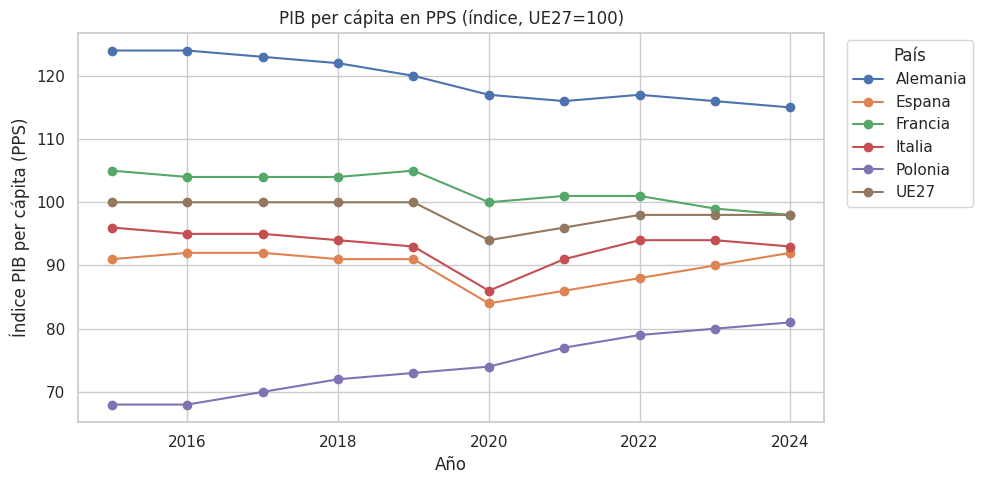

In [2]:
fig, ax = plt.subplots()
for pais, grupo in df.groupby("pais"):
    ax.plot(grupo["anio"], grupo["pib_per_capita_pps_indice"], marker="o", label=pais)

ax.set_title("PIB per cápita en PPS (índice, UE27=100)")
ax.set_xlabel("Año")
ax.set_ylabel("Índice PIB per cápita (PPS)")
ax.legend(title="País", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pib_per_capita_evolucion.png", dpi=150)
plt.show()

## 2. PIB total vs PIB per cápita: ¿crecen igual?

Comparamos el crecimiento acumulado del PIB real (tamaño total) frente al cambio en el índice de PIB per cápita, para el periodo disponible.

In [3]:
resumen = (
    df.groupby("pais")
    .apply(lambda g: pd.Series({
        "crecimiento_pib_acumulado_%": g.sort_values("anio")["pib_crecimiento_real_pct"].sum(),
        "cambio_pib_per_capita_indice": g.sort_values("anio")["pib_per_capita_pps_indice"].iloc[-1]
                                       - g.sort_values("anio")["pib_per_capita_pps_indice"].iloc[0],
    }))
    .reset_index()
    .sort_values("crecimiento_pib_acumulado_%", ascending=False)
)
resumen

,pais,crecimiento_pib_acumulado_%,cambio_pib_per_capita_indice
4,Polonia,35.8,13.0
1,Espana,21.7,1.0
5,UE27,16.4,-2.0
2,Francia,12.5,-7.0
3,Italia,10.1,-3.0
0,Alemania,9.4,-9.0


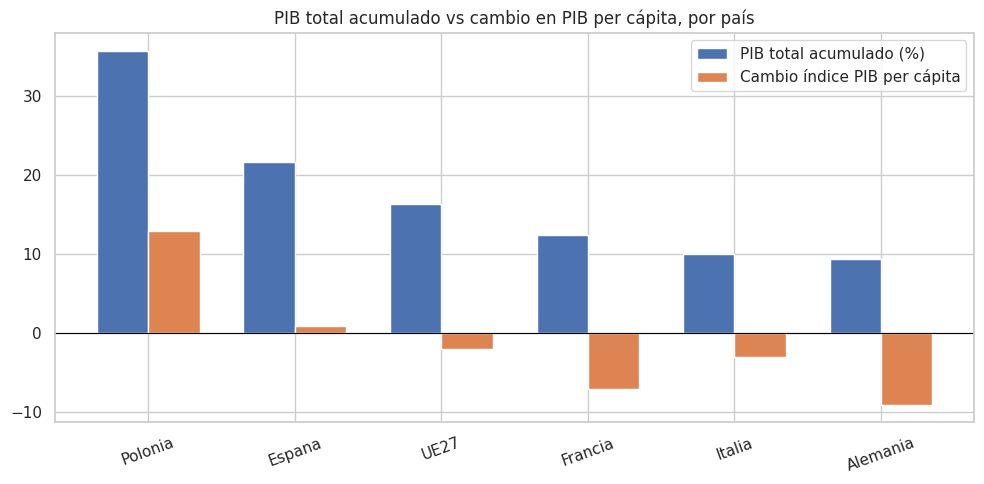

In [4]:
fig, ax = plt.subplots()
x = range(len(resumen))
width = 0.35

ax.bar([i - width/2 for i in x], resumen["crecimiento_pib_acumulado_%"], width, label="PIB total acumulado (%)")
ax.bar([i + width/2 for i in x], resumen["cambio_pib_per_capita_indice"], width, label="Cambio índice PIB per cápita")

ax.set_xticks(list(x))
ax.set_xticklabels(resumen["pais"], rotation=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("PIB total acumulado vs cambio en PIB per cápita, por país")
ax.legend()
plt.tight_layout()
plt.savefig("pib_total_vs_per_capita.png", dpi=150)
plt.show()

**Lectura del gráfico:** cuando las dos barras están muy separadas para un país, significa que el PIB total y el PIB per cápita se han movido de forma distinta — justo el fenómeno que motivó este proyecto: el tamaño de la economía puede crecer más rápido (o más lento) que el nivel de vida medio.

## 3. Ranking de PIB per cápita en el último año disponible

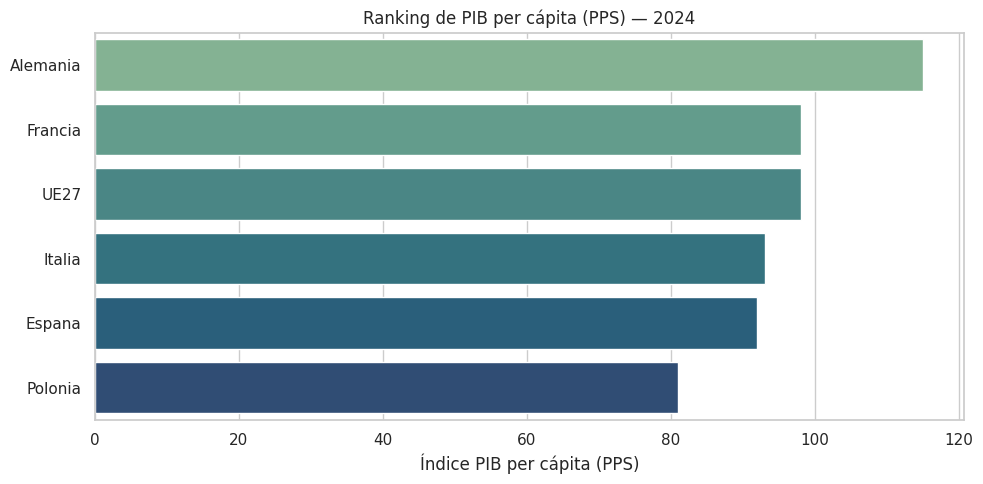

In [5]:
ultimo_anio = df["anio"].max()
ranking = (
    df[df["anio"] == ultimo_anio]
    .sort_values("pib_per_capita_pps_indice", ascending=False)
)

fig, ax = plt.subplots()
sns.barplot(data=ranking, x="pib_per_capita_pps_indice", y="pais", hue="pais", legend=False, palette="crest", ax=ax)
ax.set_title(f"Ranking de PIB per cápita (PPS) — {ultimo_anio}")
ax.set_xlabel("Índice PIB per cápita (PPS)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("ranking_pib_per_capita.png", dpi=150)
plt.show()

## Conclusiones

- El PIB total y el PIB per cápita **no siempre se mueven en la misma dirección ni a la misma velocidad**.
- Un país puede mostrar buen crecimiento agregado y, aun así, quedarse atrás en PIB per cápita si su población crece más rápido que su producción.
- Este tipo de análisis es la base para discutir de forma rigurosa debates como "¿la inmigración/una política concreta hace crecer la economía?" — la respuesta cambia mucho según qué indicador se mire.

*Nota: si este notebook se ejecutó sin `fetch_data.py`, los datos son **ilustrativos** y no deben citarse como oficiales.*